In [2]:
import torch 
import numpy as np
import pandas as pd
from transformers import RobertaTokenizer, RobertaForSequenceClassification

/home/dods/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-07 12:21:08.106364: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 12:21:08.830642: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 12:21:11.038952: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different n

In [ ]:
def plot_meta_feature_across_layers(
    df=None,
    feature_name="n2.mean",
    csv_path="/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures.csv",
    title=None,
    figsize=(9, 4),
    marker="o",
    color=None,
    ylim=None,
):
    # Load DataFrame if not provided
    if df is None:
        try:
            df = pd.read_csv(csv_path)
        except FileNotFoundError:
            df = pd.read_csv("/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures.csv")

    # Find feature (allow . or _), robust to spaces and case
    feat_col = df["feature"].astype(str)

    features_norm = (
        feat_col.str.strip()
                .str.lower()
                .str.replace(r"[._]", ".", regex=True)
    )
    name_norm = feature_name.strip().lower().replace("_", ".")

    mask = features_norm == name_norm
    df_feat = df[mask].copy()
    if df_feat.empty:
        raise ValueError(f"Feature '{feature_name}' not found.")

    # Order layers: embeddings, layer_0...layer_n, classifier_dense
    def layer_sort_key(name):
        if name == "embeddings":
            return -1
        if name in {"classifier_dense", "classifier", "classification_head", "head_dense"}:
            return 1_000_000
        m = re.match(r"^layer_(\d+)$", str(name))
        return int(m.group(1)) if m else 10_000

    layers = df_feat["layer"].astype(str)
    order = sorted(layers.unique(), key=layer_sort_key)
    df_feat["layer"] = pd.Categorical(df_feat["layer"], categories=order, ordered=True)
    df_feat = df_feat.sort_values("layer")

    # Plot
    plt.figure(figsize=figsize)
    plt.plot(df_feat["layer"].astype(str), df_feat["value"], marker=marker, color=color)
    plt.title(title or f"{feature_name} across RoBERTa layers")
    plt.xlabel("Layer")
    plt.ylabel(feature_name)
    plt.xticks(rotation=45)
    if ylim is not None:
        plt.ylim(ylim)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage
plot_meta_feature_across_layers(df=combined_meta, feature_name="f2.mean")



In [3]:
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base")
print(roberta_model)



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [4]:
import importlib
import sys, os
sys.path.append('/home/dods/matrix/IC')
import FeaturesExtraction as FE_module
importlib.reload(FE_module)
from FeaturesExtraction import FeaturesExtraction
from datasets import load_dataset

fe = FeaturesExtraction(roberta_model, roberta_tokenizer)

In [5]:
# Load dataset (GLUE RTE) and define tokenizer
rte_dataset = load_dataset("glue", "rte", split="train")

def tokenize_rte_longest(tokenizer, batch, max_length):
    return tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        padding="longest",
        truncation=True,
        max_length=max_length,
    )


In [6]:
# Extract meta-features for all layers (produces meta_df)
# Uses a stratified subset if available; falls back to a small slice for speed
_ds_all = rte_dataset  # use entire dataset

meta_df, feats_by_layer = fe.extract_all_layers_and_metafeatures(
    dataset=_ds_all,
    tokenize_fn=tokenize_rte_longest,
    batch_size=8,
    max_length=128,
    device="auto",
    pooling="cls",
    return_numpy=False,
    groups="all",
    summaries=None,
    random_state=42,
    dataset_name="glue_rte",
    token_reduce="mean",
    layer_filter=None,
    sort_numeric=True,
    return_features=True,
)

# Save the base CSV (plot function will also read this if combined CSV not present


Tokenizing:   0%|          | 0/2490 [00:00<?, ? examples/s]Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not 

In [8]:
# Uses the convenience function to extract + summarize from a single layer
target_layer = roberta_model.classifier.dense

# Use stratified subset if available; else small slice for speed
dataset_for_cls = rte_dataset  # use entire dataset

meta_cls = fe.extract_metafeatures_for_layer(
    layer=target_layer,
    dataset=dataset_for_cls,
    tokenize_fn=tokenize_rte_longest,
    batch_size=8,
    max_length=128,
    device="auto",
    pooling="cls",
    groups="all",
    summaries=None,
    random_state=42,
    dataset_name="glue_rte",
)
meta_cls["layer"] = "classifier_dense"

combined_meta = pd.concat([meta_df, meta_cls], ignore_index=True)
out_csv_combined = "/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures.csv"
combined_meta.to_csv(out_csv_combined, index=False)
print("Saved combined meta-features to:", out_csv_combined)
combined_meta.head()

2025-10-07 14:59:30,854 INFO FeaturesExtraction: Using device: cuda
2025-10-07 14:59:40,174 INFO FeaturesExtraction: Tokenized dataset columns: ['label', 'input_ids', 'attention_mask']
2025-10-07 14:59:40,175 INFO FeaturesExtraction: DataLoader ready with batch_size=8
/home/dods/miniconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1784: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
2025-10-07 14:59:57,798 INFO FeaturesExtraction: Extracted features shape: (2490, 768)
2025-10-07 14:59:57,826 INFO FeaturesExtraction: Meta-feature groups to extract: ['landmarking', 'general', 'statistical', 'model-based', 'info-theory', 'relative', 'clustering', 'complexity', 'itemset', 'concept']
2025-10-07 15:00:02,396 INFO FeaturesExtraction: Extracted 14 meta-features for group 'landmarking'
2025-10-07 15:00:02,741 INFO FeaturesExtraction: Extracted 12 meta-feature

Saved combined meta-features to: /home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures.csv


,feature,value,group,dataset,layer
0,attr_to_inst,0.308434,general,glue_rte,embeddings
1,cat_to_num,0.000000,general,glue_rte,embeddings
2,freq_class.count,2.000000,general,glue_rte,embeddings
3,freq_class.histogram.0,0.500000,general,glue_rte,embeddings
4,freq_class.histogram.1,0.000000,general,glue_rte,embeddings


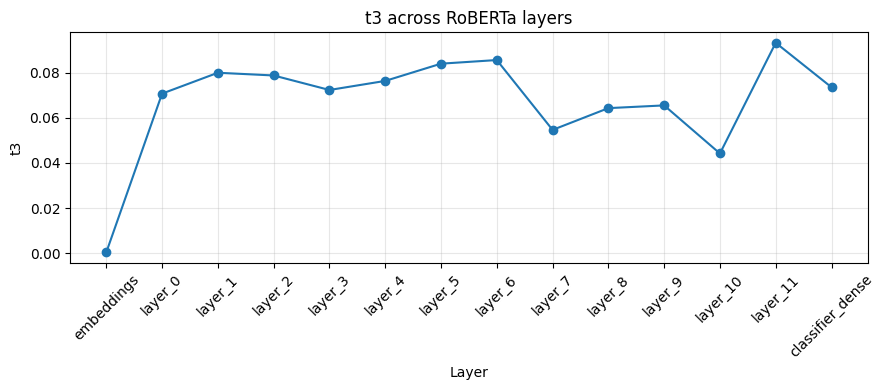

In [22]:
# Simplified plotting function for a meta-feature across layers
import re
import pandas as pd
import matplotlib.pyplot as plt

def plot_meta_feature_across_layers(
    df=None,
    feature_name="n2.mean",
    csv_path="/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures.csv",
    title=None,
    figsize=(9, 4),
    marker="o",
    color=None,
    ylim=None,
):
    # Load DataFrame if not provided
    if df is None:
        try:
            df = pd.read_csv(csv_path)
        except FileNotFoundError:
            df = pd.read_csv("/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures.csv")

    # Find feature (allow . or _)
    feat_col = df["feature"].astype(str)
    pattern = f"^{re.escape(feature_name).replace('.', '[._]')}$"
    mask = feat_col.str.lower().str.match(pattern)
    df_feat = df[mask].copy()
    if df_feat.empty:
        raise ValueError(f"Feature '{feature_name}' not found.")

    # Order layers: embeddings, layer_0...layer_n, classifier_dense
    def layer_sort_key(name):
        if name == "embeddings":
            return -1
        if name in {"classifier_dense", "classifier", "classification_head", "head_dense"}:
            return 1_000_000
        m = re.match(r"^layer_(\d+)$", name)
        return int(m.group(1)) if m else 10_000

    layers = df_feat["layer"].astype(str)
    order = sorted(layers.unique(), key=layer_sort_key)
    df_feat["layer"] = pd.Categorical(df_feat["layer"], categories=order, ordered=True)
    df_feat = df_feat.sort_values("layer")

    # Plot
    plt.figure(figsize=figsize)
    plt.plot(df_feat["layer"].astype(str), df_feat["value"], marker=marker, color=color)
    plt.title(title or f"{feature_name} across RoBERTa layers")
    plt.xlabel("Layer")
    plt.ylabel(feature_name)
    plt.xticks(rotation=45)
    if ylim is not None:
        plt.ylim(ylim)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage
plot_meta_feature_across_layers(df=meta_df, feature_name="f2.mean")


In [13]:
combined_meta[combined_meta["feature"] == "f2.mean"]

,feature,value,group,dataset,layer
2199,f2.mean,NaN,complexity,glue_rte,embeddings
6130,f2.mean,3.317379e-44,complexity,glue_rte,layer_0
10061,f2.mean,2.454303e-40,complexity,glue_rte,layer_1
13992,f2.mean,3.735593e-41,complexity,glue_rte,layer_2
17923,f2.mean,5.097501e-39,complexity,glue_rte,layer_3
21854,f2.mean,6.027842e-42,complexity,glue_rte,layer_4
25785,f2.mean,6.558225e-47,complexity,glue_rte,layer_5
29716,f2.mean,2.245654e-43,complexity,glue_rte,layer_6
33647,f2.mean,1.703728e-36,complexity,glue_rte,layer_7
37578,f2.mean,3.984075e-35,complexity,glue_rte,layer_8


In [51]:
!pip install tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 10.9 MB/s  0:00:00


In [73]:
# Ensure accelerate is installed in this kernel (version-compatible)
import sys, importlib, subprocess
try:
    importlib.import_module("accelerate")
except ModuleNotFoundError:
    print("Installing accelerate in current kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "accelerate>=0.26.0"])


In [ ]:
# Fine-tuning setup: split, tokenize, Trainer with early stopping
import transformers
importlib.reload(transformers)

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, DataCollatorWithPadding
import numpy as np

# Stratified split (train/val)
split = rte_dataset.train_test_split(test_size=0.2, seed=42, stratify_by_column="label")
train_ds = split["train"]
val_ds = split["test"]

# Tokenization for Trainer (keep as 'labels')
def _tok_for_trainer(batch):
    out = tokenize_rte_longest(roberta_tokenizer, batch, max_length=256)
    out["labels"] = batch["label"]
    return out

tok_train = train_ds.map(_tok_for_trainer, batched=True, remove_columns=train_ds.column_names)
tok_val = val_ds.map(_tok_for_trainer, batched=True, remove_columns=val_ds.column_names)

collator = DataCollatorWithPadding(roberta_tokenizer, return_tensors="pt")

# Metrics
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro"),
    }

# TrainingArguments (version-compatible)
output_dir = "/home/dods/matrix/IC/Notebooks/roberta_rte_ft"
try:
    args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        num_train_epochs=4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=50,
        seed=42,
        report_to=[],
    )
except TypeError:
    # Older transformers versions: minimal args without evaluation/save strategy
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=50,
        seed=42,
    )

# Trainer (handle older versions lacking callbacks argument)
try:
    trainer = Trainer(
        model=roberta_model,
        args=args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        data_collator=collator,
        tokenizer=roberta_tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
except TypeError:
    trainer = Trainer(
        model=roberta_model,
        args=args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        data_collator=collator,
        tokenizer=roberta_tokenizer,
        compute_metrics=compute_metrics,
    )

trainer.train()


ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=0.26.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=0.26.0'`

In [ ]:
# Save and reload best model
best_dir = trainer.state.best_model_checkpoint or output_dir
print("Best checkpoint:", best_dir)
roberta_model = RobertaForSequenceClassification.from_pretrained(best_dir)
fe = FeaturesExtraction(roberta_model, roberta_tokenizer)


In [ ]:
# Re-extract meta-features with fine-tuned model
meta_df_ft, feats_by_layer_ft = fe.extract_all_layers_and_metafeatures(
    dataset=rte_dataset,
    tokenize_fn=tokenize_rte_longest,
    batch_size=8,
    max_length=128,
    device="auto",
    pooling="cls",
    return_numpy=False,
    groups="all",
    summaries=None,
    random_state=42,
    dataset_name="glue_rte_ft",
    token_reduce="mean",
    layer_filter=None,
    sort_numeric=True,
    return_features=True,
)

out_csv_ft = "/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures_ft.csv"
meta_df_ft.to_csv(out_csv_ft, index=False)
print("Saved fine-tuned meta-features to:", out_csv_ft)


In [ ]:
# Plot comparison before vs after fine-tuning for n2.mean
try:
    _ = meta_df
except NameError:
    meta_df = pd.read_csv("/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures.csv")

try:
    _ = meta_df_ft
except NameError:
    meta_df_ft = pd.read_csv("/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures_ft.csv")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plot_meta_feature_across_layers(df=meta_df, feature_name="n2.mean", title="Before FT: n2.mean")
plt.subplot(1, 2, 2)
plot_meta_feature_across_layers(df=meta_df_ft, feature_name="n2.mean", title="After FT: n2.mean")


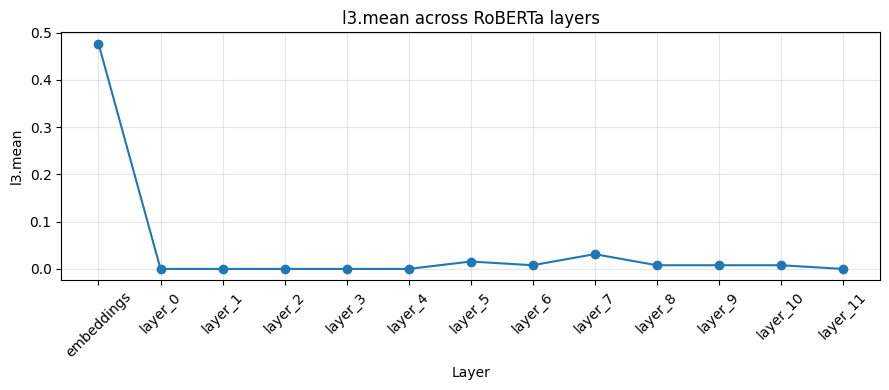

In [ ]:
plot_meta_feature_across_layers(df=meta_df if 'meta_df' in globals() else None, feature_name="l3.mean")

In [ ]:
# Extract meta-features from classifier dense layer and concatenate with all-layers
# Uses the convenience function to extract + summarize from a single layer
try:
    target_layer = roberta_model.classifier.dense
except AttributeError:
    raise AttributeError("Current model has no 'classifier.dense' layer")

# Use stratified subset if available; else small slice for speed
dataset_for_cls = subset if 'subset' in globals() else rte_dataset.select(range(128))

meta_cls = fe.extract_metafeatures_for_layer(
    layer=target_layer,
    dataset=dataset_for_cls,
    tokenize_fn=tokenize_rte_longest,
    batch_size=8,
    max_length=128,
    device="auto",
    pooling="cls",
    groups="all",
    summaries=None,
    random_state=42,
    dataset_name="glue_rte",
)
meta_cls["layer"] = "classifier_dense"

combined_meta = pd.concat([meta_df, meta_cls], ignore_index=True)
out_csv_combined = "/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures_with_classifier.csv"
combined_meta.to_csv(out_csv_combined, index=False)
print("Saved combined meta-features to:", out_csv_combined)
combined_meta.head()


In [ ]:
# Robust redefinition: normalize feature names (handles '.' vs '_', spaces, case)

def plot_meta_feature_across_layers(
    df=None,
    feature_name="n2.mean",
    csv_path="/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures.csv",
    title=None,
    figsize=(9, 4),
    marker="o",
    color=None,
    ylim=None,
):
    # Load DataFrame if not provided
    if df is None:
        try:
            df = pd.read_csv(csv_path)
        except FileNotFoundError:
            df = pd.read_csv("/home/dods/matrix/IC/Notebooks/roberta_layers_metafeatures.csv")

    # Find feature (allow . or _), robust to spaces and case
    feat_col = df["feature"].astype(str)
    features_norm = (
        feat_col.str.strip()
                .str.lower()
                .str.replace(r"[._]", ".", regex=True)
    )
    name_norm = feature_name.strip().lower().replace("_", ".")

    mask = features_norm == name_norm
    df_feat = df[mask].copy()
    if df_feat.empty:
        raise ValueError(f"Feature '{feature_name}' not found.")

    # Order layers: embeddings, layer_0...layer_n, classifier_dense
    def layer_sort_key(name):
        if name == "embeddings":
            return -1
        if name in {"classifier_dense", "classifier", "classification_head", "head_dense"}:
            return 1_000_000
        m = re.match(r"^layer_(\d+)$", str(name))
        return int(m.group(1)) if m else 10_000

    layers = df_feat["layer"].astype(str)
    order = sorted(layers.unique(), key=layer_sort_key)
    df_feat["layer"] = pd.Categorical(df_feat["layer"], categories=order, ordered=True)
    df_feat = df_feat.sort_values("layer")

    # Plot
    plt.figure(figsize=figsize)
    plt.plot(df_feat["layer"].astype(str), df_feat["value"], marker=marker, color=color)
    plt.title(title or f"{feature_name} across RoBERTa layers")
    plt.xlabel("Layer")
    plt.ylabel(feature_name)
    plt.xticks(rotation=45)
    if ylim is not None:
        plt.ylim(ylim)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage (uses combined_meta if available; else the function loads CSV)
plot_meta_feature_across_layers(df=combined_meta if 'combined_meta' in globals() else None, feature_name="f2.mean")

